In [1]:
# ==========================================
# STEP 1: LOAD AND PREPROCESS DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

# Load dataset
df = pd.read_csv('diabetes.csv')

# Handle missing values
df = df.dropna()

# Rename target column to 'Disease' if needed to match the teaching guide
if 'Outcome' in df.columns:
    df.rename(columns={'Outcome': 'Disease'}, inplace=True)

# Separate features (X) and target (y)
X = df.drop('Disease', axis=1)
y = df['Disease']  # 0 = No, 1 = Yes

# Check class balance
print("Class Balance:")
print(y.value_counts())

# Split data: 80% train, 20% test (stratified to preserve class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




Class Balance:
Disease
0    500
1    268
Name: count, dtype: int64


In [2]:
# ==========================================
# STEP 2: LOGISTIC REGRESSION
# ==========================================
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("\n--- Logistic Regression Results ---")
print(f"Accuracy:  {acc_lr:.3f}")
print(f"Precision: {prec_lr:.3f}")
print(f"Recall:    {rec_lr:.3f}")
print(f"F1-Score:  {f1_lr:.3f}")


--- Logistic Regression Results ---
Accuracy:  0.747
Precision: 0.609
Recall:    0.778
F1-Score:  0.683


In [3]:
# ==========================================
# STEP 3: DECISION TREE CLASSIFIER
# ==========================================
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("\n--- Decision Tree Results ---")
print(f"Accuracy:  {acc_dt:.3f}")
print(f"Precision: {prec_dt:.3f}")
print(f"Recall:    {rec_dt:.3f}")
print(f"F1-Score:  {f1_dt:.3f}")

# Select the best model based on F1-Score
if f1_dt >= f1_lr:
    best_model = dt_model
    best_pred = y_pred_dt
    model_name = "Decision Tree"
else:
    best_model = lr_model
    best_pred = y_pred_lr
    model_name = "Logistic Regression"


--- Decision Tree Results ---
Accuracy:  0.883
Precision: 0.781
Recall:    0.926
F1-Score:  0.847



Confusion Matrix (Decision Tree):
[[86 14]
 [ 4 50]]


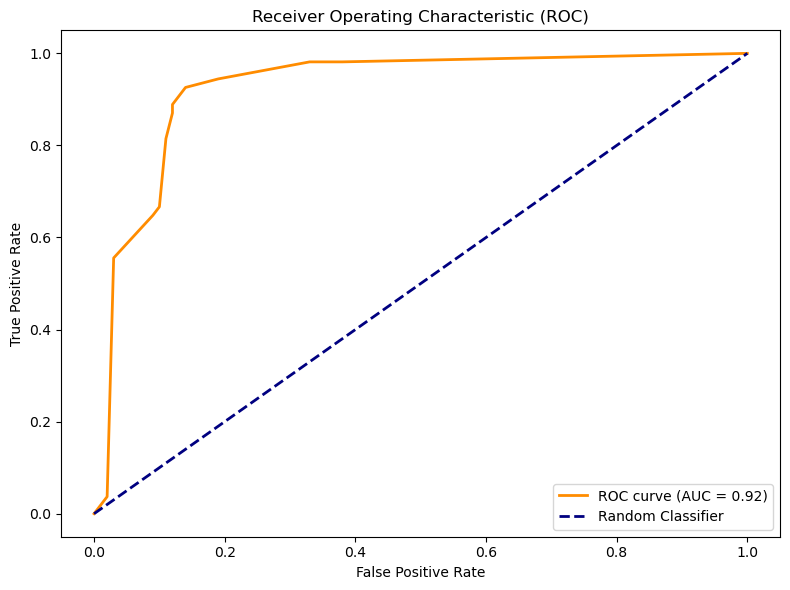

In [4]:

# ==========================================
# STEP 4: CONFUSION MATRIX & ROC CURVE
# ==========================================
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
print(f"\nConfusion Matrix ({model_name}):")
print(cm)

# ROC Curve
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()


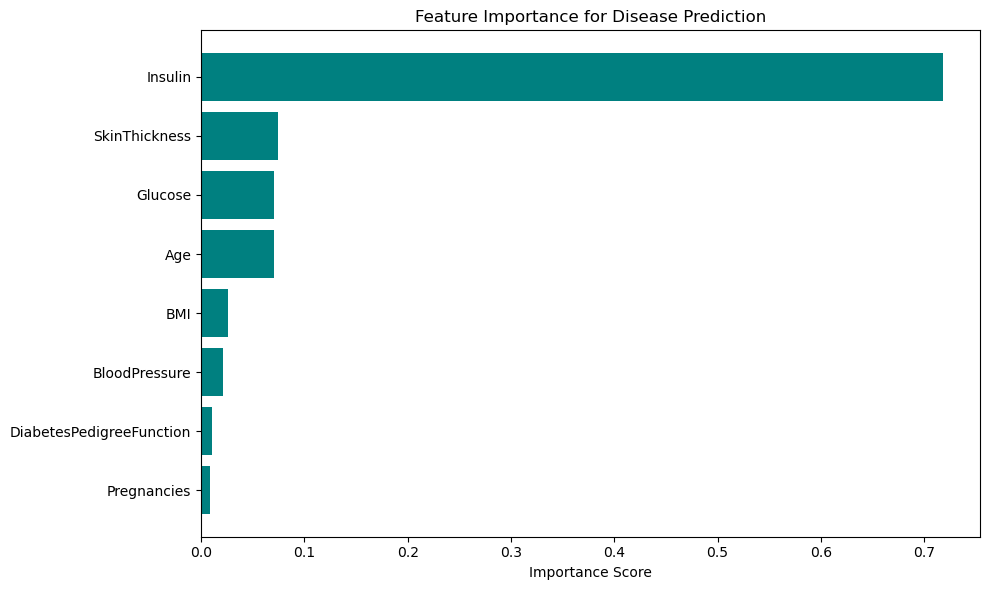

In [5]:
# ==========================================
# STEP 5: FEATURE IMPORTANCE
# ==========================================
importances = dt_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importance for Disease Prediction')
plt.tight_layout()
plt.savefig('feature_importance_disease.png')
plt.show()


In [6]:

# ==========================================
# STEP 6: SERIALIZATION FOR DEPLOYMENT
# ==========================================
joblib.dump(dt_model, 'disease_model.pkl')
joblib.dump(scaler, 'disease_scaler.pkl')
joblib.dump(list(X.columns), 'disease_features.pkl')
print("\nSaved 'disease_model.pkl', 'disease_scaler.pkl', and 'disease_features.pkl' successfully!")


Saved 'disease_model.pkl', 'disease_scaler.pkl', and 'disease_features.pkl' successfully!


In [7]:

# ==========================================
# STEP 7: FINAL REPORT
# ==========================================
print("=" * 60)
print("DISEASE PREDICTION MODEL REPORT")
print("=" * 60)
print(f"Dataset Size:   {len(df)}")
print(f"Disease Cases:  {sum(y)}")
print(f"Healthy Cases:  {len(y) - sum(y)}")
print(f"\nBest Model Performance ({model_name}):")
print(f"  Accuracy:  {max(acc_lr, acc_dt):.1%}")
print(f"  Precision: {max(prec_lr, prec_dt):.1%}")
print(f"  Recall:    {max(rec_lr, rec_dt):.1%}")
print(f"  F1-Score:  {max(f1_lr, f1_dt):.3f}")
print(f"\nTop 3 Important Features:")
print(importance_df.sort_values('Importance', ascending=False).head(3))

DISEASE PREDICTION MODEL REPORT
Dataset Size:   768
Disease Cases:  268
Healthy Cases:  500

Best Model Performance (Decision Tree):
  Accuracy:  88.3%
  Precision: 78.1%
  Recall:    92.6%
  F1-Score:  0.847

Top 3 Important Features:
         Feature  Importance
4        Insulin    0.718006
3  SkinThickness    0.074688
1        Glucose    0.070852
